# ML Lab 2 Tasks
<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marcinsawinski/UEP_KIE_ML_CLASS/blob/main/02_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### Note! Check hints in [Cheatsheet](https://colab.research.google.com/github/marcinsawinski/UEP_KIE_ML_CLASS/blob/main/00_cheatsheet.ipynb)

# Task 2.1
_Get data from url_housing and visualize_
- Preview data, get statistics (.head(), .inf(), .describe())
- Print data histogram


_Type your code below_

In [829]:
import pandas as pd
import numpy as np
import urllib.request
from matplotlib import pyplot as plt
from narwhals import DataFrame
from sklearn import svm
from sklearn.metrics import root_mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.utils.validation import check_is_fitted

In [830]:
url = "https://github.com/marcinsawinski/UEP_KIE_ML_CLASS/raw/main/datasets/housing/housing.csv"
filename = "data/housing.csv"

# This saves the file to your disk and returns the local path
local_path, headers = urllib.request.urlretrieve(url, filename)

# Now load the SAVED file
housing = pd.read_csv(local_path)
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [831]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [832]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [833]:
housing["median_income"].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

(array([   9.,   14.,   61.,  255.,  538.,  676.,  546.,  803.,  881.,
         706.,  812.,  715.,  836.,  815.,  921.,  960.,  786.,  817.,
         703.,  505.,  620.,  661.,  578.,  508.,  437.,  434.,  463.,
         331.,  320.,  216.,  224.,  232.,  245.,  252.,  286.,  193.,
         160.,  149.,  117.,  133.,  104.,   99.,   80.,   90.,  106.,
          66.,   49.,   51.,   47., 1030.]),
 array([ 14999.  ,  24699.04,  34399.08,  44099.12,  53799.16,  63499.2 ,
         73199.24,  82899.28,  92599.32, 102299.36, 111999.4 , 121699.44,
        131399.48, 141099.52, 150799.56, 160499.6 , 170199.64, 179899.68,
        189599.72, 199299.76, 208999.8 , 218699.84, 228399.88, 238099.92,
        247799.96, 257500.  , 267200.04, 276900.08, 286600.12, 296300.16,
        306000.2 , 315700.24, 325400.28, 335100.32, 344800.36, 354500.4 ,
        364200.44, 373900.48, 383600.52, 393300.56, 403000.6 , 412700.64,
        422400.68, 432100.72, 441800.76, 451500.8 , 461200.84, 470900.88,
        

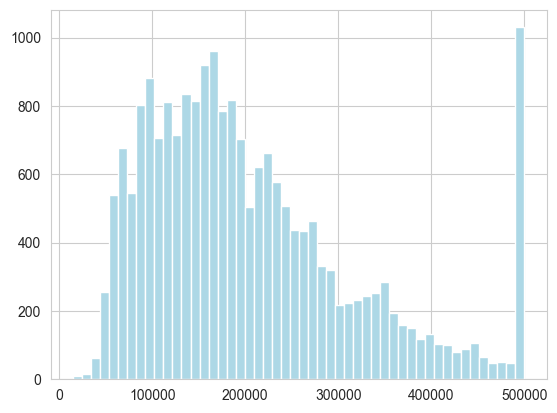

In [834]:
plt.hist(
    x = housing["median_house_value"],
    bins= 50,
    label = "Median Value",
    color = "lightblue",
    edgecolor = "white"
)

# Task 2.2
_Create train / test split (80/20)_
- Create random split
- Create stratifed split on income class (5 strata)


_Type your code below_

In [835]:
housing["income_cat"] = pd.qcut(housing["median_income"],
                                q=5,
                                labels=[1, 2, 3, 4, 5])

In [836]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score

X = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    train_size=0.8, test_size=0.2,
                                                    stratify=housing['income_cat'],
                                                    random_state=42,
                                                    )
housing.drop('income_cat', axis=1, inplace=True)

# Task 2.3
_Visualize_
- Create plot using geographical data (lang, lat). Add alpha. Add color for median_house_value. Add size for population. OPTIONAL Add basemap (e.g. plotly.express)
- Create correlation matrix
- Plot correlation for median_income and median_house_value

_Explore_
 - Make train dataframe  copy
 - Create 3 new features:
    - rooms_per_household  = total_rooms / households,
    - bedrooms_per_room = total_bedrooms / total_rooms
    - population_per_household = population / households
- Check correlation of new features

_Type your code below_

In [837]:
import plotly.express as px
import seaborn as sns

In [838]:
fig = px.scatter_map(
    housing,
    lat="latitude",
    lon="longitude",
    color="median_house_value",
    size="population",
    color_continuous_scale="Blues",
    opacity=0.5,             # alpha
    map_style="carto-positron",
    title="California Housing Prices",
    labels={'median_house_value': 'House Value ($)', 'population': 'Population'},
    height=700,
    zoom = 5
)

# Improves the margin so the map fills the window
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

fig.show()

In [839]:
corr_housing = housing.drop(['longitude','latitude','ocean_proximity'],axis=1).corr()
corr_housing.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
housing_median_age,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843


<Axes: xlabel='median_house_value', ylabel='median_income'>

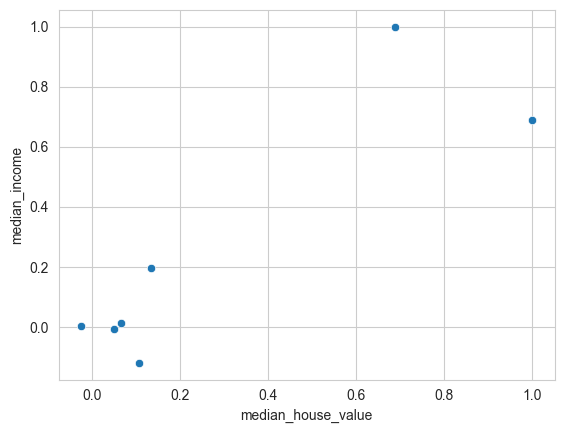

In [840]:
sns.scatterplot(corr_housing,
               x="median_house_value",
                y="median_income")

In [841]:
X_train_copy = X_train.copy()
X_train_copy["rooms_per_household"] = X_train_copy["total_rooms"]/X_train_copy["households"]
X_train_copy["bedrooms_per_room"] = X_train_copy["total_bedrooms"]/X_train_copy["total_rooms"]
X_train_copy["population_per_household"] = X_train_copy["population"]/X_train_copy["households"]

In [842]:
corr_housing_copy = X_train_copy.drop(['longitude', 'latitude', 'ocean_proximity'],axis=1).corr()

<Axes: >

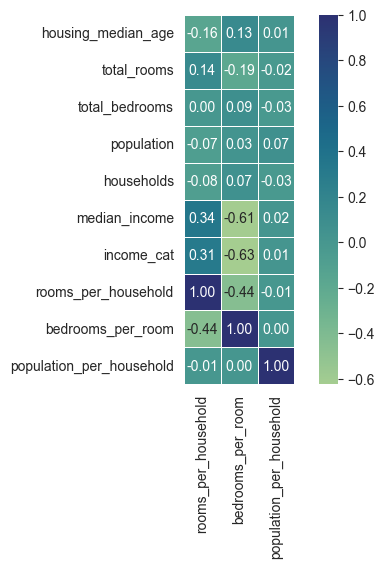

In [843]:
sns.heatmap(corr_housing_copy[["rooms_per_household", "bedrooms_per_room", "population_per_household"]],
            annot=True,
            cmap="crest",
            fmt=".2f",
            linecolor="white",
            linewidths=.5,
            square=True)

# Task 2.4
_Prepare_
- Make train dataframe copy, drop label
- Make train dataframe copy with label only

_Clean_
 - Fill missing total_bedrooms with median value ( whe using inputer watch out for categorical features)
 - Convert categorical features into one-hot features


_Type your code below_

In [844]:
from sklearn.impute import SimpleImputer
median_impute = SimpleImputer(strategy="median")
X_train["total_bedrooms"] = median_impute.fit_transform(X_train[["total_bedrooms"]])
X_train = pd.get_dummies(X_train, columns=["ocean_proximity"])
X_test = pd.get_dummies(X_test, columns=["ocean_proximity"])

# Task 2.5
_Clean_
- Remove outliers with Isolation forest
- Standardize numerical variables
- Try fixing distribution od population variable using:
    - log function
    - percentiles
- Add rbf measure for value 35 of housing_median_age


_Type your code below_

In [845]:
from sklearn.ensemble import IsolationForest
isolforest = IsolationForest()
labels = isolforest.fit_predict(X_train, y_train)

In [846]:
X_train['is_outlier'] = labels

In [847]:
'''mask = X_train["is_outlier"] != -1

X_train = X_train[mask]
y_train = y_train[mask]

X_train = X_train.drop(columns=["is_outlier"])
y_train = y_train.drop(columns=["is_outlier"]) if isinstance(y_train, pd.DataFrame) else y_train'''

'mask = X_train["is_outlier"] != -1\n\nX_train = X_train[mask]\ny_train = y_train[mask]\n\nX_train = X_train.drop(columns=["is_outlier"])\ny_train = y_train.drop(columns=["is_outlier"]) if isinstance(y_train, pd.DataFrame) else y_train'

In [848]:
X_train = X_train[X_train["is_outlier"] != -1]

y_train = y_train.loc[X_train.index]

X_train = X_train.drop(columns=["is_outlier"])

In [849]:
columns = X_train.columns

_Note:_ Commenting features for easier later handling

In [850]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

In [851]:
X_train = pd.DataFrame(X_train, columns=columns)
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,income_cat,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
1333,-119.81,34.44,23.0,3172.0,588.0,1467.0,559.0,4.6806,4,False,False,False,False,True
16948,-117.66,34.00,5.0,1387.0,236.0,855.0,270.0,5.4110,5,False,True,False,False,False
7572,-122.48,37.75,49.0,2203.0,407.0,1052.0,405.0,4.4375,4,False,False,False,True,False
4754,-117.59,34.10,17.0,3646.0,1035.0,1987.0,895.0,2.3603,2,False,True,False,False,False
17733,-121.93,37.31,26.0,2182.0,704.0,1638.0,704.0,2.8981,2,True,False,False,False,False


In [852]:
X_test = pd.DataFrame(X_test, columns=columns)

<Axes: xlabel='population', ylabel='Count'>

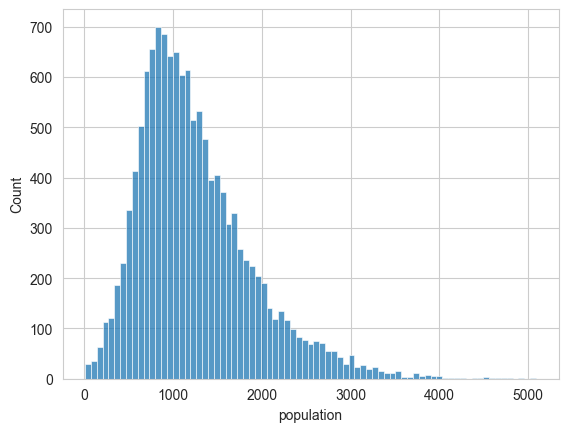

In [853]:
sns.histplot(X_train["population"])

In [854]:
from scipy.stats import kurtosis
print(f"Kurtosis of population feature: {kurtosis(X_train['population'])}")
skew = np.mean((X_train['population'] - np.mean(X_train['population']))**3) / np.std(X_train['population'])**3
print(f"Skewness of population feature: {skew}")

Kurtosis of population feature: 2.0004141118868946
Skewness of population feature: 1.1650718126098958


In [855]:
X_train["population"].describe()

count    13059.000000
mean      1253.775863
std        644.456394
min         13.000000
25%        800.000000
50%       1129.000000
75%       1580.000000
max       5087.000000
Name: population, dtype: float64

In [856]:
q99 = X_train["population"].quantile(0.99)
X_train["population"] = X_train["population"].clip(upper=q99)

print(f"New Max: {X_train['population'].max()}")

New Max: 3259.42


<Axes: xlabel='population', ylabel='Count'>

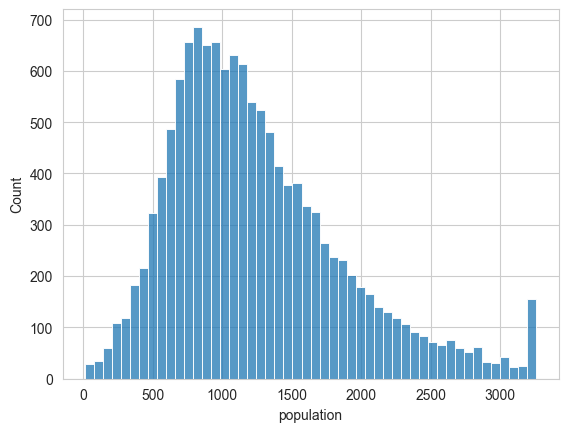

In [857]:
sns.histplot(X_train["population"])

In [858]:
from sklearn.metrics.pairwise import rbf_kernel

age_column = X_train[["housing_median_age"]]
X_train["age_rbf_35"] = rbf_kernel(age_column, [[35]], gamma=0.1)

# Task 2.6
_Generate custom transformations_
- add log transformer for population
- add rbf measure for value 35 of housing_median_age
- add 10 KMeans clusters
- add rooms_per_house, people_per_house, bedrooms_ratio (last one optional set by hyperparamter)

_Generate custom pipeline to combine transformations__
- pipeline for preprocessing the numerical attributes
    - median inputer
    - attributs adder
    - StandardScaler
- full pipeline witn numerical pipeline the numerical attributes and OneHotEncoder for categorical attributes

_Type your code below_

_Log transformation is not possible/useful since in previous step the feature's kurtosis and skewness have been operated on._ <br>
_Clustering on longitude and latitude because it is more interesting :D_

In [859]:
X_geo = X_train[['latitude', 'longitude']]

In [860]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 10, n_init = 10, random_state = 42)

In [861]:
X_train['clusters'] = kmeans.fit_predict(X_geo)

In [862]:
X_test['clusters'] = kmeans.predict(X_test[['latitude', 'longitude']])

In [863]:
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,income_cat,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,age_rbf_35,clusters
1333,-119.81,34.44,23.0,3172.0,588.0,1467.0,559.0,4.6806,4,False,False,False,False,True,5.573904e-07,2
16948,-117.66,34.00,5.0,1387.0,236.0,855.0,270.0,5.4110,5,False,True,False,False,False,8.194013e-40,7
7572,-122.48,37.75,49.0,2203.0,407.0,1052.0,405.0,4.4375,4,False,False,False,True,False,3.074880e-09,3
4754,-117.59,34.10,17.0,3646.0,1035.0,1987.0,895.0,2.3603,2,False,True,False,False,False,8.489044e-15,7
17733,-121.93,37.31,26.0,2182.0,704.0,1638.0,704.0,2.8981,2,True,False,False,False,False,3.035391e-04,3


In [864]:
def adding_ratios(data):
    data['rooms_per_household'] = data['total_rooms']/data['households']
    data['people_per_house'] = data['population']/data['households']
    data['bedrooms_ratio'] = data['total_bedrooms']/data['total_rooms']
    return data

In [865]:
def attr_adder(data, age_col = 'housing_median_age'):
    from sklearn.cluster import KMeans
    from sklearn.metrics.pairwise import rbf_kernel

    data = adding_ratios(data)
    kmeans = KMeans(n_clusters = 10, n_init = 10, random_state = 42)
    data['clusters'] = kmeans.fit_predict(data)
    data["age_rbf_35"] = rbf_kernel(data[[age_col]], [[35]], gamma=0.1)

    return data

In [866]:
from sklearn.preprocessing import FunctionTransformer
attr_adder_transformer = FunctionTransformer(attr_adder)

In [867]:
#X_train = adding_ratios(X_train)
#X_test = adding_ratios(X_test)

In [868]:
# Dynamically create 5 bins with equal number of data points
housing["income_cat"] = pd.qcut(housing["median_income"],
                                q=5,
                                labels=[1, 2, 3, 4, 5])
from sklearn.model_selection import train_test_split
X = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    train_size=0.8, test_size=0.2,
                                                    stratify=housing['income_cat'],
                                                    random_state=42,
                                                    )
housing.drop('income_cat', axis=1, inplace=True)

In [869]:
from sklearn.pipeline import Pipeline
median_imputer = SimpleImputer(strategy="median")
median_imputer.set_output(transform="pandas")
scaler = StandardScaler()
scaler.set_output(transform="pandas")
num_pipeline = Pipeline(steps=[
    ('imputer', median_imputer),
    ('attributes adder', attr_adder_transformer),
    ('scaler', scaler)
])

In [870]:
from sklearn.preprocessing import OneHotEncoder
cat_pipeline = Pipeline(steps=[
    ('one hot encoding', OneHotEncoder(handle_unknown='ignore'))
])

In [871]:
num_values = X_train.drop(['ocean_proximity'], axis=1).columns

In [872]:
cat_value = ['ocean_proximity']

In [873]:
from sklearn.compose import ColumnTransformer
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_values),
    ('cat', cat_pipeline, cat_value)
])

In [874]:
X_train_prep = full_pipeline.fit_transform(X_train)
X_test_prep = full_pipeline.transform(X_test)

# Task 2.7
_Select and Train a Model_
- Fit LinearRegression on data prepared with full pipline. Check SME, RSME and MAE
- Fit DecisionTreeRegressor. Check RSME.
- Fit RandomForestRegressor. Check RSME.
- Fit SVR. Check RSME.
- Peforem cross validation(cv=10). Compare results

_Type your code below_

In [875]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [876]:
models = {"Linear Regression": LinearRegression(),
          "Decision Tree Regressor": DecisionTreeRegressor(),
          "Random Forest": RandomForestRegressor(),
          "SVR": SVR()}

In [877]:
model_performance = {}
model_csv = {}

for name, model in models.items():
    model.fit(X_train_prep, y_train)

    predictions = model.predict(X_test_prep)
    score = root_mean_squared_error(y_test, predictions)

    kf = KFold(n_splits=10, random_state=42, shuffle=True)
    cv_score = cross_val_score(model, X_test_prep, y_test, cv=kf, scoring="neg_mean_squared_error")

    model_performance[name] = score
    model_csv[name] = cv_score

print(model_performance)
print(model_csv)

{'Linear Regression': 66910.91589905946, 'Decision Tree Regressor': 69843.52030558106, 'Random Forest': 47912.53162958406, 'SVR': 116558.46015640881}
{'Linear Regression': array([-4.62635846e+09, -4.95393506e+09, -5.57079962e+09, -3.92494814e+09,
       -5.76433978e+09, -4.66779415e+09, -4.49985031e+09, -4.38549692e+09,
       -4.11774322e+09, -3.84535133e+09]), 'Decision Tree Regressor': array([-6.37308983e+09, -6.49354930e+09, -5.78613438e+09, -6.65589295e+09,
       -6.06257019e+09, -6.22946489e+09, -5.94447485e+09, -5.15045264e+09,
       -5.11064926e+09, -5.67817241e+09]), 'Random Forest': array([-2.71701104e+09, -2.90562542e+09, -2.51837627e+09, -2.78397932e+09,
       -2.88913137e+09, -3.66940136e+09, -2.85753724e+09, -2.54796180e+09,
       -2.48136856e+09, -2.36014837e+09]), 'SVR': array([-1.50018836e+10, -1.38994659e+10, -1.49386544e+10, -1.17435787e+10,
       -1.33781728e+10, -1.41570102e+10, -1.34099283e+10, -1.45939754e+10,
       -1.22701326e+10, -1.31250868e+10])}


# Task 2.8
_Tune Model_
- Tune DecisionTreeRegressor with Grid Search with param grid:
```python
param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]
```
- Tune DecisionTreeRegressor with RandomizedSearchCV
```python
param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }
```
- Check scores
- Check feature importances

_Type your code below_

_Changing estimator tuning to RandomForestRegressor since DecisionTreeRegresor has no n_estimators to tune as well as is not the best performing model based on RMSE and csv from previous task._

In [878]:
param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

In [879]:
from sklearn.model_selection import GridSearchCV
random_forest = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(random_forest, param_grid=param_grid)
grid_search.fit(X_train_prep, y_train)
print(f"RMSE: {root_mean_squared_error(y_test, grid_search.predict(X_test_prep))}")
print(f"Best params: {grid_search.best_params_}")

RMSE: 48037.89811124912
Best params: {'max_features': 8, 'n_estimators': 30}


In [880]:
from scipy.stats import randint
param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }

In [881]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(random_forest, param_distributions=param_distribs)
random_search.fit(X_train_prep, y_train)
print(f"RMSE: {root_mean_squared_error(y_test, random_search.predict(X_test_prep))}")
print(f"Best params: {random_search.best_params_}")

RMSE: 47482.54530035341
Best params: {'max_features': 7, 'n_estimators': 124}


In [882]:
random_forest = RandomForestRegressor(random_state=42, max_features=7, n_estimators=44)
random_forest.fit(X_train_prep, y_train)
random_forest.feature_importances_

array([6.74658517e-02, 6.01511335e-02, 3.84826151e-02, 1.66639427e-02,
       1.59659112e-02, 1.68949940e-02, 1.55966696e-02, 2.38221101e-01,
       1.52675275e-01, 4.97329885e-02, 1.05262092e-01, 5.09294121e-02,
       3.87441892e-03, 9.71607798e-03, 1.18412602e-02, 1.38494691e-01,
       1.85608084e-04, 3.65174656e-03, 4.19421088e-03])

# Task 2.9
_Evaluate Your System on the Test Set_
- Predict result for test set with best_estimator. Check RSME.
- Calcualte 95% confidence interval for the test RMSE

_Type your code below_

In [883]:
best_estimator = RandomForestRegressor(
    max_features=7,
    n_estimators=44,
)
best_estimator.fit(X_train_prep, y_train)
pred = best_estimator.predict(X_test_prep)
print(f"RMSE: {root_mean_squared_error(y_test, pred)}")

RMSE: 47578.05292827383


In [884]:
from scipy import stats

squared_errors = (pred - y_test) ** 2

confidence = 0.95
m = len(squared_errors)
mean = squared_errors.mean()

t_score = stats.t.interval(confidence, df=m - 1, loc=mean, scale=stats.sem(squared_errors))

rmse_confidence_interval = np.sqrt(t_score)

print(f"95% Confidence Interval for RMSE: {rmse_confidence_interval}")

95% Confidence Interval for RMSE: [45503.56280683 49565.79478608]


# Task 2.10
Extra tasks:
- Write a full pipeline with both preparation and prediction (full_pipeline and LinearRegression)
- Calculate 10 clusters and add RBF similarities features


_Type your code below_

In [885]:
from sklearn.base import BaseEstimator, TransformerMixin, MetaEstimatorMixin


class ClusterAndRBFFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, rbf_gamma=0.1, age_target=35):
        self.n_clusters = n_clusters
        self.rbf_gamma = rbf_gamma
        self.age_target = age_target

    def fit(self, X, y=None):
        # Only fitting long and lat features - better interpretation
        self.kmeans = KMeans(n_clusters=self.n_clusters, n_init=10, random_state=42)
        self.kmeans.fit(X.iloc[:, [0, 1]])
        return self

    def transform(self, X):
        # Cluster distances can be used for more details
        # cluster_distances = self.kmeans.transform(X[:, [0, 1]])
        clusters = self.kmeans.predict(X.iloc[:, [0, 1]])

        age_column = X.iloc[:, [2]]
        age_rbf = rbf_kernel(age_column, [[self.age_target]], gamma=self.rbf_gamma)

        # Concatenate original features with new features
        return np.c_[X, clusters, age_rbf]

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np

class ClusterAndRBFFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, rbf_gamma=0.1, age_target=35):
        # Rule: Assign parameters exactly as they appear in the constructor
        self.n_clusters = n_clusters
        self.rbf_gamma = rbf_gamma
        self.age_target = age_target

    def fit(self, X, y=None):
        # Use the parameter from __init__ to create the model here
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, n_init=10, random_state=42)

        # Using .iloc handles both DataFrames and NumPy-like objects
        self.kmeans_.fit(X.iloc[:, [0, 1]])

        # Standard sklearn: return self and save feature_names_in_
        self.feature_names_in_ = X.columns.tolist() if hasattr(X, "columns") else None
        return self

    def transform(self, X):
        # Use the fitted model (with the underscore _)
        clusters = self.kmeans_.predict(X.iloc[:, [0, 1]])

        # Ensure age_column is 2D for rbf_kernel
        age_column = X.iloc[:, [2]].values.reshape(-1, 1)
        age_rbf = rbf_kernel(age_column, [[self.age_target]], gamma=self.rbf_gamma)

        # Concatenate: Original X (2D) + clusters (reshaped to 2D) + age_rbf (2D)
        return np.c_[X, clusters.reshape(-1, 1), age_rbf]

    def get_feature_names_out(self, input_features=None):
        # If the task requires this method, define the new names
        names = list(input_features) if input_features is not None else ["feat_" + str(i) for i in range(len(self.feature_names_in_))]
        return names + ["cluster", "age_rbf"]

**Overriding** the **ClusterAndRBFFeatures** to ensure its compatible with 2.15 randomized search

In [907]:
class ClusterAndRBFFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, rbf_gamma=0.1, age_target=35):
        self.n_clusters = n_clusters
        self.rbf_gamma = rbf_gamma
        self.age_target = age_target

    def fit(self, X, y=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, n_init=10, random_state=42)
        self.kmeans_.fit(X.iloc[:, [0, 1]])
        self.feature_names_in_ = X.columns.tolist() if hasattr(X, "columns") else None
        return self

    def transform(self, X):
        clusters = self.kmeans_.predict(X.iloc[:, [0, 1]])
        age_column = X.iloc[:, [2]].values.reshape(-1, 1)
        age_rbf = rbf_kernel(age_column, [[self.age_target]], gamma=self.rbf_gamma)
        return np.c_[X, clusters.reshape(-1, 1), age_rbf]

    def get_feature_names_out(self, input_features=None):
        names = list(input_features) if input_features is not None else ["feat_" + str(i) for i in range(len(self.feature_names_in_))]
        return names + ["cluster", "age_rbf"]

In [908]:
num_pipeline = Pipeline(steps=[
    ('imputer', median_imputer),
    ('attributes adder', attr_adder_transformer),
    ('clusters and rfb', ClusterAndRBFFeatures()),
    ('scaler', scaler)
])

In [909]:
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_values),
    ('cat', cat_pipeline, cat_value)
])

In [910]:
full_prediction_pipeline = Pipeline(steps=[
    ('preprocessing', full_pipeline),
    ('predictions', LinearRegression()),
])

# Task 2.11
_Try a Support Vector Machine regressor (`sklearn.svm.SVR`) with various hyperparameters, such as `kernel="linear"` (with various values for the `C` hyperparameter) or `kernel="rbf"` (with various values for the `C` and `gamma` hyperparameters). Note that SVMs don't scale well to large datasets, so you should probably train your model on just the first 5,000 instances of the training set and use only 3-fold cross-validation, or else it will take hours. How does the best `SVR` predictor perform?

In [911]:
X_train_prep_2 = full_pipeline.fit_transform(X_train)

In [912]:
X_train_prep_2 = X_train_prep_2[:5000, :]
y_train_2 = y_train.iloc[:5000]

In [913]:
svm_param_grid = [
    {'kernel': ['rbf', 'poly', 'sigmoid', 'linear'], 'gamma': ['scale', 'auto'],
     'C' : [0.1, 1.0, 10.0, 100.0]},
  ]

In [914]:
svr = SVR()
svm_grid_search = GridSearchCV(svr, param_grid=svm_param_grid)
svm_grid_search.fit(X_train_prep_2, y_train_2)
print(f'Best params: {svm_grid_search.best_params_}')

KeyboardInterrupt: 

# Task 2.12
_Try replacing the `GridSearchCV` with a `RandomizedSearchCV`._


In [915]:
from scipy.stats import loguniform, uniform
svm_param_dist = [
    {'kernel': ['rbf', 'poly', 'sigmoid', 'linear'],
     'gamma': loguniform(0.01, 1),
     'C': uniform(0.1, 100)}
]

In [916]:
svm_rand_search = RandomizedSearchCV(svr, param_distributions=svm_param_dist)
svm_rand_search.fit(X_train_prep_2, y_train_2)
print(f'Best params: {svm_rand_search.best_params_}')

KeyboardInterrupt: 

# Task 2.13
_Try adding a `SelectFromModel` transformer in the preparation pipeline to select only the most important attributes._

In [917]:
from sklearn.feature_selection import SelectFromModel
selector = SelectFromModel(RandomForestRegressor(n_estimators=100, random_state=42))
full_prediction_pipeline_selector = Pipeline(steps=[
    ('preprocessing', full_pipeline),
    ('selector', selector),
    ('predictions', LinearRegression())
])

# Task 2.14

_Try creating a custom transformer that trains a k-Nearest Neighbors regressor (`sklearn.neighbors.KNeighborsRegressor`) in its `fit()` method, and outputs the model's predictions in its `transform()` method. Then add this feature to the preprocessing pipeline, using latitude and longitude as the inputs to this transformer. This will add a feature in the model that corresponds to the housing median price of the nearest districts._

Rather than restrict ourselves to k-Nearest Neighbors regressors, let's create a transformer that accepts any regressor. For this, we can extend the `MetaEstimatorMixin` and have a required `estimator` argument in the constructor. The `fit()` method must work on a clone of this estimator, and it must also save `feature_names_in_`. The `MetaEstimatorMixin` will ensure that `estimator` is listed as a required parameters, and it will update `get_params()` and `set_params()` to make the estimator's hyperparameters available for tuning. Lastly, we create a `get_feature_names_out()` method: the output column name is the ...


In [896]:
from sklearn.neighbors import KNeighborsRegressor

In [918]:
class GeoClassCreator1(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=5, weights="uniform",algorithm = "auto", leaf_size=30):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.algorithm = algorithm
        self.leaf_size = leaf_size
        self.knn = KNeighborsRegressor(n_neighbors=self.n_neighbors, weights=self.weights, algorithm=self.algorithm, leaf_size= self.leaf_size)

    def fit(self, X, y):
        X = X[['longitude', 'latitude']]
        self.knn.fit(X, y)
        return self

    def transform(self, X):
        X = X[['longitude', 'latitude']]
        return self.knn.predict(X)

In [919]:
from sklearn.base import MetaEstimatorMixin, clone

In [935]:
class ChameleonEstimator(MetaEstimatorMixin, BaseEstimator, TransformerMixin):
    def __init__(self, estimator=None):
        self.estimator = estimator
    def fit(self, X, y):
        self.estimator_ = clone(self.estimator)
        self.feature_names_in_ = X.columns if hasattr(X, "columns") else None
        self.estimator_.fit(X,y)
        return self
    def predict(self, X):
        check_is_fitted(self.estimator_)
        pred = self.estimator_.predict(X)
        return pred.reshape(-1,1)
    def get_feature_names_out(self, input_features = None):
        class_name = self.estimator.__class__.__name__.lower()
        return [f"{class_name}_prediction"]

# Task 2.15
_Automatically explore some preparation options using `RandomSearchCV`._


In [936]:
full_prediction_pipeline_selector = Pipeline(steps=[
    ('preprocessing', full_pipeline),
    ('selector', selector),
    ('predictions', ChameleonEstimator(estimator=LinearRegression()))
])

In [937]:
param_dist = [
    {
        'predictions__estimator': [KNeighborsRegressor()],
        'predictions__estimator__n_neighbors': randint(2, 20),
        'predictions__estimator__weights': ['uniform', 'distance']
    },
    {
        'predictions__estimator': [RandomForestRegressor(random_state=42)],
        'predictions__estimator__n_estimators': randint(50, 200),
        'predictions__estimator__max_depth': [None, 10, 20]
    }
]

In [938]:
rnd_search = RandomizedSearchCV(
    full_prediction_pipeline_selector,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error'
)

In [939]:
rnd_search.fit(X_train, y_train)
print(f'Best params: {rnd_search.best_params_}')

KeyboardInterrupt: 

# Task 2.16
_Try to implement the `StandardScalerClone` class again from scratch, then add support for the `inverse_transform()` method: executing `scaler.inverse_transform(scaler.fit_transform(X))` should return an array very close to `X`. Then add support for feature names: set `feature_names_in_` in the `fit()` method if the input is a DataFrame. This attribute should be a NumPy array of column names. Lastly, implement the `get_feature_names_out()` method: it should have one optional `input_features=None` argument. If passed, the method should check that its length matches `n_features_in_`, and it should match `feature_names_in_` if it is defined, then `input_features` should be returned. If `input_features` is `None`, then the method should return `feature_names_in_` if it is defined or `np.array(["x0", "x1", ...])` with length `n_features_in_` otherwise._

In [940]:
from sklearn.utils.validation import check_is_fitted, check_array

In [941]:
class StandardScalerClone (BaseEstimator, TransformerMixin):
    def fit(self, X):
        X = check_array(X)
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in = X.shape[1]
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.array(X.columns, dtype=object)
        elif isinstance(X, pd.DataFrame): # Alternative check
            self.feature_names_in_ = np.array(X.columns, dtype=object)
        return self
    def transform(self, X):
        check_is_fitted(self)
        X = check_array(X)
        return (X - self.mean_) / self.scale_
    def inverse_transform(self, X):
        check_is_fitted(self)
        X = check_array(X)
        return (X * self.scale_) + self.mean_
    def get_feature_names_out(self, input_features = None):
        if input_features is not None:
            if len(input_features) != self.n_features_in_:
                raise ValueError("Invalid number of features")
            if hasattr(self, "feature_names_in_") and not np.array_equal(input_features, self.feature_names_in_):
                raise ValueError("input_features do not match feature_names_in_")
            return np.array(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.array([f"x{i}" for i in range(self.n_features_in_)], dtype=object)